<a href="https://colab.research.google.com/github/cv326/Convex-Optimization-Term-Project/blob/main/Convex_Optimization_Term_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
import matplotlib.pyplot as plt
import os
import numpy as np
import skimage.io as io
from skimage import io, img_as_float
from skimage.util import random_noise
from skimage.color import rgb2gray
from scipy.sparse.linalg import LinearOperator, cg
from skimage.metrics import peak_signal_noise_ratio, structural_similarity, mean_squared_error
from numpy.random import f

In [ ]:
# Total variation gradient operator used in Sum(|(∇xu)i|+|(∇yu)i|)
# ∇u where Du = (u_k+1 - u_k, ..., uk+n - u_k)
def grad_operator(x):
    grad_x = np.diff(x, axis=0, append=x[-1:,:])
    grad_y = np.diff(x, axis=1, append=x[:,-1:])
    return np.stack([grad_x, grad_y], axis=0)

In [ ]:
# Implementation of anisotropic total variation - Sum(|(∇xu)i|+|(∇yu)i|)
def anisotropic_tv(x):
    grad = grad_operator(x)
    return np.sum(np.abs(grad[0]) + np.abs(grad[1]))

In [ ]:
# TV denoising objective function - used for tracking progress
# fidelity term + regularization term = (1/2)*||u-b||^2 + ​λ*TV(u)
def tv_denoising_obj(u, b, lam):
    fidelity_term = 0.5 * np.sum((u-b)**2)
    regularization_term = lam * anisotropic_tv(u)
    return fidelity_term + regularization_term

In [ ]:
# Divergence Operator - D^T - used for x update
def div_operator(grad_matrix):
    grad_x, grad_y = grad_matrix[0], grad_matrix[1]
    result = np.zeros_like(grad_x)
    result[:-1,:] -= grad_x[:-1,:]
    result[1:,:] += grad_x[:-1,:]
    result[:,:-1] -= grad_y[:,:-1]
    result[:,1:] += grad_y[:,:-1]
    return result

In [ ]:
# compute soft-threshold for update
def soft_threshold(x, threshold):
    return np.sign(x) * np.maximum(np.abs(x) - threshold, 0)

In [ ]:
# ADMM Anisotropic Implementation
# b = noisy image, lam = lambda, rho = penalty, max_iter = exit condition
def anisotropic_tv_admm(b, lam, rho, max_iter):
    # initializing variables used by admm functions
    # arrays for tracking convergence
    obj_val = []
    primal_res = []
    dual_res = []
    # image height, width, and number of pixels
    h,w = b.shape
    num_pix = h*w
    # u = denoised image, starts as noisy image
    u = b.copy()
    # variable splitting - d = ∇u
    d = grad_operator(u)
    # dual variable multiplier - gamma
    gam = np.zeros_like(d)

    # Lagrangian rewritten in scaled form:
    # original: L(u,d,gam)=​0.5||u-b||^2 + λ(||d||1) + gam^T(∇u - d) ​+ (rho/2)||∇u - d||^2
    # scaled: L(u,d,gam)=​0.5||u-b||^2 + (rho/2)||Du - d + gam||^2
    #   equvalently: (I + rho*D^T*D)u = b + rho*D^T*(d-gam)
    # linear operator formula for left hand side - Au: (I + rho*D^T*D)u
    def lin_op_lhs(x):
        x_img = x.reshape(h,w)
        Au = x_img + rho*div_operator(grad_operator(x_img))
        return Au.ravel()
    # matrix function A_mat for update linear operator (more efficient + less memory)
    A_mat = LinearOperator((num_pix, num_pix), matvec=lin_op_lhs, dtype=np.float64)


    # admm update loop
    for k in range(max_iter):
        d_prev = d.copy()

        # u - update
        # solve for the d = ∇u constraint (original formula Ax = b)
        b_vect = b + rho * div_operator(d-gam)
        # conjugate gradient solves scaled legrangian efficiently for large matices:
        #   (I + rho*D^T*D)u = b + rho*D^T*(d-gam)
        u_flat, info = cg(A_mat, b_vect.ravel(), x0=u.ravel(), rtol=1e-6,maxiter=100)
        if info != 0:
            print(f"cg did not converge at k = {k} - info={info}")
        u = u_flat.reshape(h,w)

        # dx = Du
        Du = grad_operator(u)
        # d - update
        d = soft_threshold(Du + gam, lam/rho)

        # gamma - update
        gam = gam + (Du - d)

        # record info for tracking convergence
        primal_residual = np.sqrt(np.sum(((Du-d).ravel())**2))
        dual_residual = np.sqrt(np.sum(((rho * div_operator(d - d_prev).ravel())**2)))
        obj = tv_denoising_obj(u, b, lam)
        primal_res.append(primal_residual)
        dual_res.append(dual_residual)
        obj_val.append(obj)
        if (k%40 == 0 or k == max_iter-1):
            print(f"k: {k} | obj: {obj:.4e} | primal_res: {primal_residual:.4e} | dual_res: {dual_residual:.4e}")

    # enforce that pixel values are within valid range
    final_img = np.clip(u, 0, 1)
    return final_img, obj_val, primal_res, dual_res

In [ ]:
## Image import + preprocessing
# import dataset from Kaggle:
path = kagglehub.dataset_download("balraj98/berkeley-segmentation-dataset-500-bsds500")
# select images to process, change image to see different results
# We used 118035, 24063, 106025, 181018, 372047, 55067
img_path_1 = path + '/images/train/118035.jpg'
img1 = io.imread(img_path_1)

# preprocessing img
# normalize to floating point img (easier to work with)
norm_img1 = img_as_float(rgb2gray(img1))

# add gaussian noise to image
variance = 0.0064
noisy_img1 = random_noise(norm_img1, mode='gaussian', var=variance)

# enforce valide values for pixels
noisy_img1 = np.clip(noisy_img1, 0, 1)

# RUn the Algorithm and Evaluate
# Run the ADMM Denoising algorithm on sample image using different lambda and rho values
# rho - 0.2, 2, 10
print('Running ADMM Denoising - lambda = 0.08, rho = 0.2')
denoised_img1, obj_val1, primal_res1, dual_res1 = anisotropic_tv_admm(noisy_img1, lam=0.08, rho=0.2, max_iter=200)
print('Running ADMM Denoising - lambda = 0.08, rho = 2')
denoised_img2, obj_val2, primal_res2, dual_res2 = anisotropic_tv_admm(noisy_img1, lam=0.08, rho=2, max_iter=200)
print('Running ADMM Denoising - lambda = 0.08, rho = 10')
denoised_img3, obj_val3, primal_res3, dual_res3 = anisotropic_tv_admm(noisy_img1, lam=0.08, rho=10, max_iter=200)
# lambda - 0.02, 0.08, 0.2
print('Running ADMM Denoising - lambda = 0.02, rho = 2')
denoised_img4, obj_val4, primal_res4, dual_res4 = anisotropic_tv_admm(noisy_img1, lam=0.02, rho=2, max_iter=200)
print('Running ADMM Denoising - lambda = 0.08, rho = 2')
denoised_img5, obj_val5, primal_res5, dual_res5 = anisotropic_tv_admm(noisy_img1, lam=0.08, rho=2, max_iter=200)
print('Running ADMM Denoising - lambda = 0.2, rho = 2')
denoised_img6, obj_val6, primal_res6, dual_res6 = anisotropic_tv_admm(noisy_img1, lam=0.2, rho=2, max_iter=200)

Using Colab cache for faster access to the 'berkeley-segmentation-dataset-500-bsds500' dataset.
Running ADMM Denoising - lambda = 0.08, rho = 0.2
k: 0 | obj: 2.1068e+03 | primal_res: 6.2579e+01 | dual_res: 2.6422e+01
k: 40 | obj: 6.2216e+02 | primal_res: 7.5489e-01 | dual_res: 2.4138e-02
k: 80 | obj: 6.1636e+02 | primal_res: 3.8302e-01 | dual_res: 9.1001e-03
k: 120 | obj: 6.1441e+02 | primal_res: 2.5771e-01 | dual_res: 5.2851e-03
k: 160 | obj: 6.1343e+02 | primal_res: 1.9578e-01 | dual_res: 3.2197e-03
k: 199 | obj: 6.1284e+02 | primal_res: 1.5917e-01 | dual_res: 2.5433e-03
Running ADMM Denoising - lambda = 0.08, rho = 2
k: 0 | obj: 2.1068e+03 | primal_res: 1.9381e+01 | dual_res: 7.9692e+01
k: 40 | obj: 6.1183e+02 | primal_res: 9.1192e-02 | dual_res: 8.7927e-02
k: 80 | obj: 6.1086e+02 | primal_res: 3.7256e-02 | dual_res: 2.6330e-02
k: 120 | obj: 6.1057e+02 | primal_res: 2.0140e-02 | dual_res: 1.1645e-02
k: 160 | obj: 6.1045e+02 | primal_res: 1.2908e-02 | dual_res: 6.2432e-03
k: 199 | ob

In [ ]:
# Evaluation
# psnr : peak signal to noise ratio
# ssim : structural similarity
# mse : mean square error

# noisy baseline values
pnsr_noisy1 = peak_signal_noise_ratio(norm_img1, noisy_img1, data_range=1)
ssim_noisy1 = structural_similarity(norm_img1, noisy_img1, data_range=1)
mse_noisy1 = mean_squared_error(norm_img1, noisy_img1)

# rho comparison
pnsr_denoised1 = peak_signal_noise_ratio(norm_img1, denoised_img1, data_range=1)
ssim_denoised1 = structural_similarity(norm_img1, denoised_img1, data_range=1)
mse_denoised1 = mean_squared_error(norm_img1, denoised_img1)
print("lambda = 0.08, rho = 0.2")
print(f"\tPSNR: \tNoisy:\t\t{pnsr_noisy1} \n\t\tDenoised:\t{pnsr_denoised1} ")
print(f"\tSSIM: \tNoisy:\t\t{ssim_noisy1} \n\t\tDenoised:\t{ssim_denoised1} ")
print(f"\tMSE: \tNoisy:\t\t{mse_noisy1} \n\t\tDenoised:\t{mse_denoised1} ")

pnsr_denoised2 = peak_signal_noise_ratio(norm_img1, denoised_img2, data_range=1)
ssim_denoised2 = structural_similarity(norm_img1, denoised_img2, data_range=1)
mse_denoised2 = mean_squared_error(norm_img1, denoised_img2)
print("lambda = 0.08, rho = 2")
print(f"\tPSNR: \tNoisy:\t\t{pnsr_noisy1} \n\t\tDenoised:\t{pnsr_denoised2} ")
print(f"\tSSIM: \tNoisy:\t\t{ssim_noisy1} \n\t\tDenoised:\t{ssim_denoised2} ")
print(f"\tMSE: \tNoisy:\t\t{mse_noisy1} \n\t\tDenoised:\t{mse_denoised2} ")

pnsr_denoised3 = peak_signal_noise_ratio(norm_img1, denoised_img3, data_range=1)
ssim_denoised3 = structural_similarity(norm_img1, denoised_img3, data_range=1)
mse_denoised3 = mean_squared_error(norm_img1, denoised_img3)
print("lambda = 0.08, rho = 10")
print(f"\tPSNR: \tNoisy:\t\t{pnsr_noisy1} \n\t\tDenoised:\t{pnsr_denoised3} ")
print(f"\tSSIM: \tNoisy:\t\t{ssim_noisy1} \n\t\tDenoised:\t{ssim_denoised3} ")
print(f"\tMSE: \tNoisy:\t\t{mse_noisy1} \n\t\tDenoised:\t{mse_denoised3} ")

# lambda compare
pnsr_denoised4 = peak_signal_noise_ratio(norm_img1, denoised_img4, data_range=1)
ssim_denoised4  = structural_similarity(norm_img1, denoised_img4, data_range=1)
mse_denoised4 = mean_squared_error(norm_img1, denoised_img4)
print("lambda = 0.02, rho = 2")
print(f"\tPSNR: \tNoisy:\t\t{pnsr_noisy1} \n\t\tDenoised:\t{pnsr_denoised4} ")
print(f"\tSSIM: \tNoisy:\t\t{ssim_noisy1} \n\t\tDenoised:\t{ssim_denoised4} ")
print(f"\tMSE: \tNoisy:\t\t{mse_noisy1} \n\t\tDenoised:\t{mse_denoised4} ")

pnsr_denoised5 = peak_signal_noise_ratio(norm_img1, denoised_img5, data_range=1)
ssim_denoised5 = structural_similarity(norm_img1, denoised_img5, data_range=1)
mse_denoised5 = mean_squared_error(norm_img1, denoised_img5)
print("lambda = 0.08, rho = 2")
print(f"\tPSNR: \tNoisy:\t\t{pnsr_noisy1} \n\t\tDenoised:\t{pnsr_denoised5} ")
print(f"\tSSIM: \tNoisy:\t\t{ssim_noisy1} \n\t\tDenoised:\t{ssim_denoised5} ")
print(f"\tMSE: \tNoisy:\t\t{mse_noisy1} \n\t\tDenoised:\t{mse_denoised5} ")

pnsr_denoised6 = peak_signal_noise_ratio(norm_img1, denoised_img6, data_range=1)
ssim_denoised6 = structural_similarity(norm_img1, denoised_img6, data_range=1)
mse_denoised6 = mean_squared_error(norm_img1, denoised_img6)
print("lambda = 0.2, rho = 2")
print(f"\tPSNR: \tNoisy:\t\t{pnsr_noisy1} \n\t\tDenoised:\t{pnsr_denoised6} ")
print(f"\tSSIM: \tNoisy:\t\t{ssim_noisy1} \n\t\tDenoised:\t{ssim_denoised6} ")
print(f"\tMSE: \tNoisy:\t\t{mse_noisy1} \n\t\tDenoised:\t{mse_denoised6} ")


lambda = 0.08, rho = 0.2
	PSNR: 	Noisy:		22.650863582416765 
		Denoised:	30.277367878035058 
	SSIM: 	Noisy:		0.3335969600595892 
		Denoised:	0.9212956575415764 
	MSE: 	Noisy:		0.005431423184245525 
		Denoised:	0.0009381304059332306 
lambda = 0.08, rho = 2
	PSNR: 	Noisy:		22.650863582416765 
		Denoised:	30.272902670128666 
	SSIM: 	Noisy:		0.3335969600595892 
		Denoised:	0.9201663462977824 
	MSE: 	Noisy:		0.005431423184245525 
		Denoised:	0.0009390954427126905 
lambda = 0.08, rho = 10
	PSNR: 	Noisy:		22.650863582416765 
		Denoised:	30.272658102616585 
	SSIM: 	Noisy:		0.3335969600595892 
		Denoised:	0.9200916534599499 
	MSE: 	Noisy:		0.005431423184245525 
		Denoised:	0.0009391483281884623 
lambda = 0.02, rho = 2
	PSNR: 	Noisy:		22.650863582416765 
		Denoised:	27.435534655073216 
	SSIM: 	Noisy:		0.3335969600595892 
		Denoised:	0.5749799432307829 
	MSE: 	Noisy:		0.005431423184245525 
		Denoised:	0.0018048725276181826 
lambda = 0.08, rho = 2
	PSNR: 	Noisy:		22.650863582416765 
		Denoised:	30

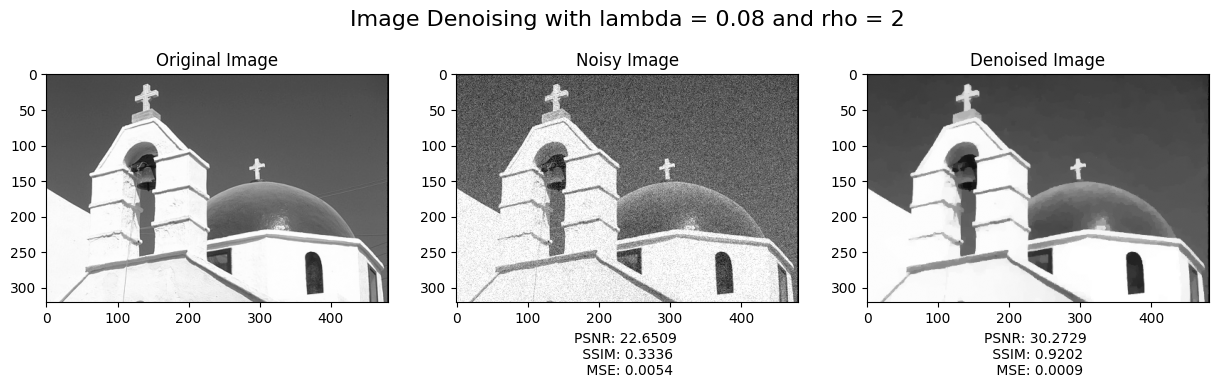

In [ ]:
# Show Image 1 Results
plt.figure(figsize=(15,4))
plt.title('Image Denoising with lambda = 0.08 and rho = 2', fontsize=16)
plt.axis('off')
plt.subplot(1,3,1)
plt.imshow(norm_img1, cmap='gray')
plt.title('Original Image')
plt.subplot(1,3,2)
plt.imshow(noisy_img1, cmap='gray')
plt.title('Noisy Image')
plt.xlabel(f'PSNR: {pnsr_noisy1:.4f} \n SSIM: {ssim_noisy1:.4f} \n MSE: {mse_noisy1:.4f}')
plt.subplot(1,3,3)
plt.imshow(denoised_img5, cmap='gray')
plt.title('Denoised Image')
plt.xlabel(f'PSNR: {pnsr_denoised5:.4f} \n SSIM: {ssim_denoised5:.4f} \n MSE: {mse_denoised5:.4f}')
plt.show()

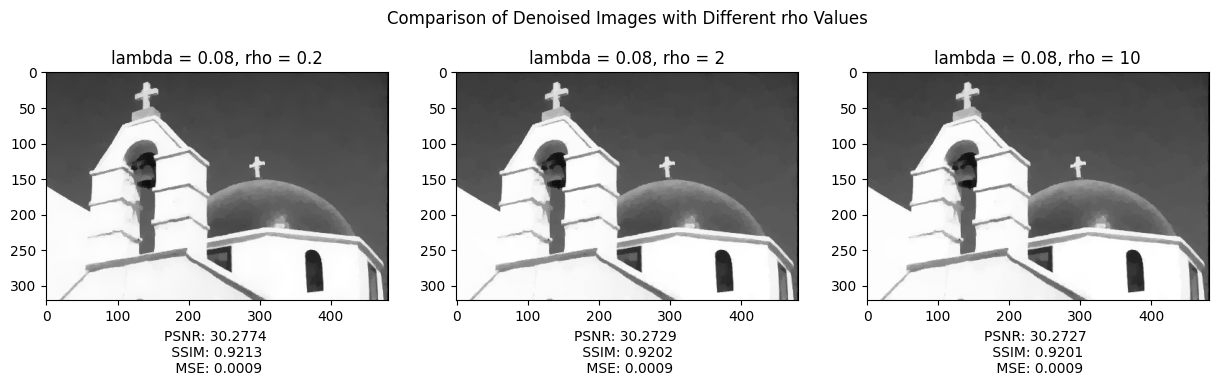

In [ ]:
# rho image Compare:
plt.figure(figsize=(15,4))
plt.title('Comparison of Denoised Images with Different rho Values')
plt.axis('off')
plt.subplot(1,3,1)
plt.imshow(denoised_img1, cmap='gray')
plt.title('lambda = 0.08, rho = 0.2')
plt.xlabel(f'PSNR: {pnsr_denoised1:.4f} \n SSIM: {ssim_denoised1:.4f} \n MSE: {mse_denoised1:.4f}')
plt.subplot(1,3,2)
plt.imshow(denoised_img2, cmap='gray')
plt.title('lambda = 0.08, rho = 2')
plt.xlabel(f'PSNR: {pnsr_denoised2:.4f} \n SSIM: {ssim_denoised2:.4f} \n MSE: {mse_denoised2:.4f}')
plt.subplot(1,3,3)
plt.imshow(denoised_img3, cmap='gray')
plt.title('lambda = 0.08, rho = 10')
plt.xlabel(f'PSNR: {pnsr_denoised3:.4f} \n SSIM: {ssim_denoised3:.4f} \n MSE: {mse_denoised3:.4f}')
plt.show()

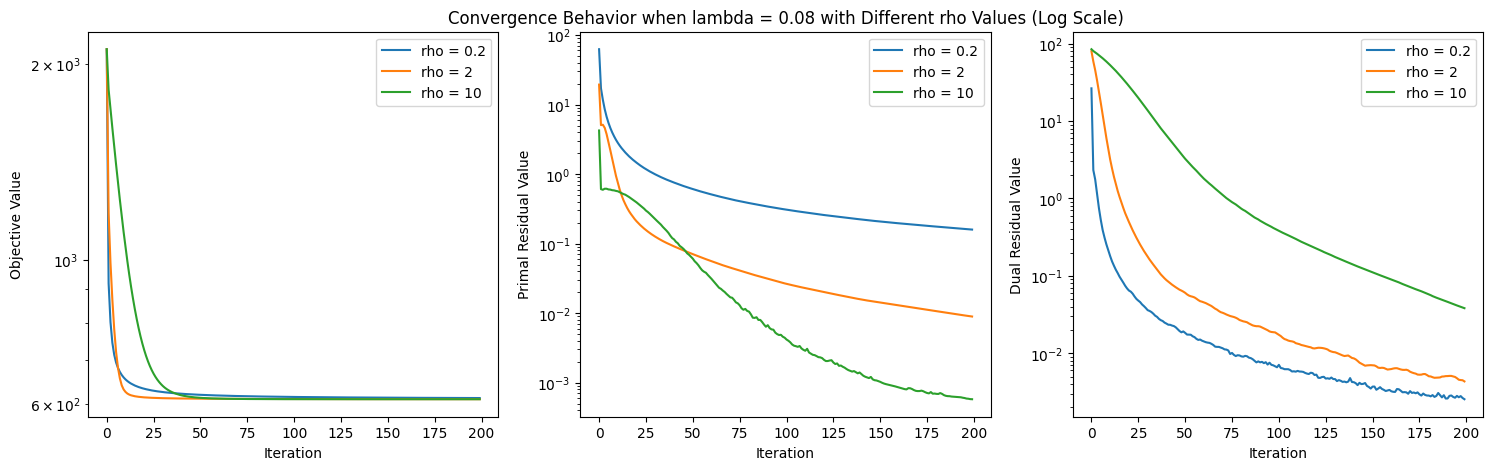

In [ ]:
# rho convergence comparison:
plt.figure(figsize=(18,5))
plt.title('Convergence Behavior when lambda = 0.08 with Different rho Values (Log Scale)')
plt.axis('off')
plt.subplot(1,3,1)
plt.semilogy(obj_val1, label='rho = 0.2')
plt.semilogy(obj_val2, label='rho = 2')
plt.semilogy(obj_val3, label='rho = 10')
plt.xlabel('Iteration')
plt.ylabel('Objective Value')
plt.legend()
plt.subplot(1,3,2)
plt.semilogy(primal_res1, label='rho = 0.2')
plt.semilogy(primal_res2, label='rho = 2')
plt.semilogy(primal_res3, label='rho = 10')
plt.xlabel('Iteration')
plt.ylabel('Primal Residual Value')
plt.legend()
plt.subplot(1,3,3)
plt.semilogy(dual_res1, label='rho = 0.2')
plt.semilogy(dual_res2, label='rho = 2')
plt.semilogy(dual_res3, label='rho = 10')
plt.xlabel('Iteration')
plt.ylabel('Dual Residual Value')
plt.legend()
plt.show()


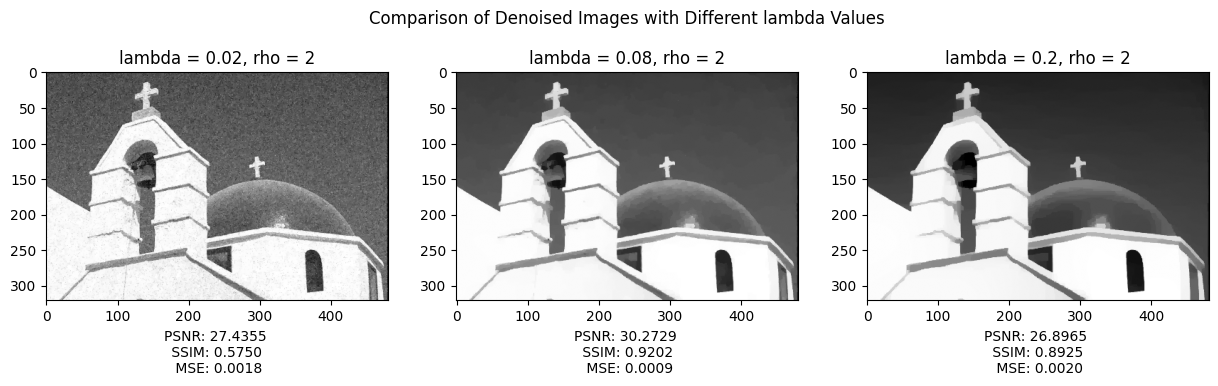

In [ ]:
# lambda image compare
plt.figure(figsize=(15,4))
plt.title('Comparison of Denoised Images with Different lambda Values')
plt.axis('off')
plt.subplot(1,3,1)
plt.imshow(denoised_img4, cmap='gray')
plt.title('lambda = 0.02, rho = 2')
plt.xlabel(f'PSNR: {pnsr_denoised4:.4f} \n SSIM: {ssim_denoised4:.4f} \n MSE: {mse_denoised4:.4f}')
plt.subplot(1,3,2)
plt.imshow(denoised_img5, cmap='gray')
plt.title('lambda = 0.08, rho = 2')
plt.xlabel(f'PSNR: {pnsr_denoised5:.4f} \n SSIM: {ssim_denoised5:.4f} \n MSE: {mse_denoised5:.4f}')
plt.subplot(1,3,3)
plt.imshow(denoised_img6, cmap='gray')
plt.title('lambda = 0.2, rho = 2')
plt.xlabel(f'PSNR: {pnsr_denoised6:.4f} \n SSIM: {ssim_denoised6:.4f} \n MSE: {mse_denoised6:.4f}')
plt.show()

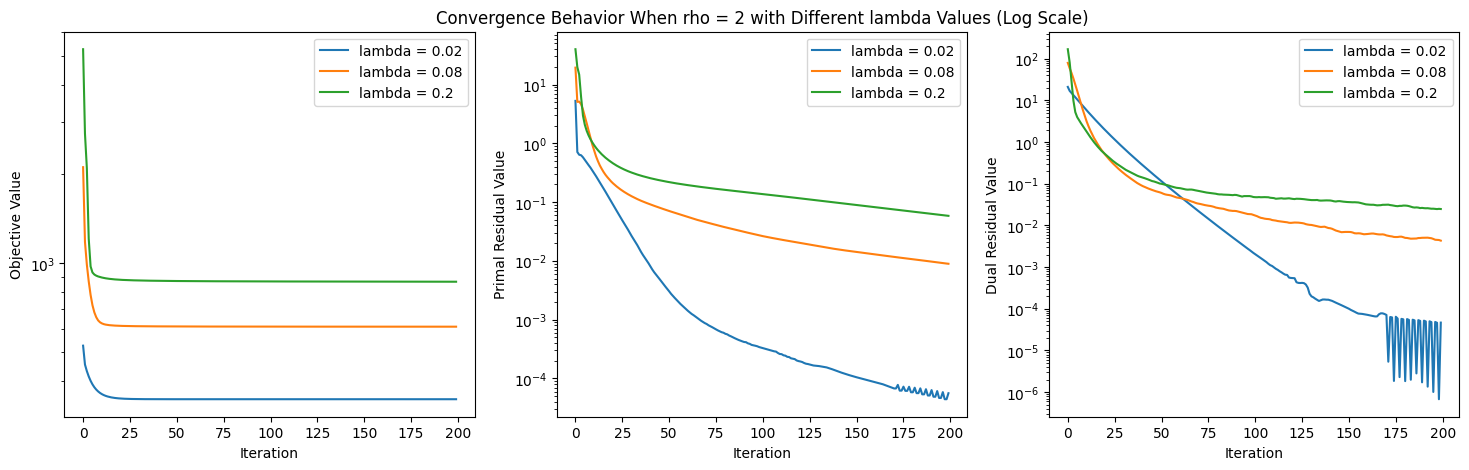

In [ ]:
# lambda convergence behavior
plt.figure(figsize=(18,5))
plt.title('Convergence Behavior When rho = 2 with Different lambda Values (Log Scale)')
plt.axis('off')
plt.subplot(1,3,1)
plt.semilogy(obj_val4, label='lambda = 0.02')
plt.semilogy(obj_val5, label='lambda = 0.08')
plt.semilogy(obj_val6, label='lambda = 0.2')
plt.xlabel('Iteration')
plt.ylabel('Objective Value')
plt.legend()
plt.subplot(1,3,2)
plt.semilogy(primal_res4, label='lambda = 0.02')
plt.semilogy(primal_res5, label='lambda = 0.08')
plt.semilogy(primal_res6, label='lambda = 0.2')
plt.xlabel('Iteration')
plt.ylabel('Primal Residual Value')
plt.legend()
plt.subplot(1,3,3)
plt.semilogy(dual_res4, label='lambda = 0.02')
plt.semilogy(dual_res5, label='lambda = 0.08')
plt.semilogy(dual_res6, label='lambda = 0.2')
plt.xlabel('Iteration')
plt.ylabel('Dual Residual Value')
plt.legend()
plt.show()

In [ ]:
# compare pnsr at different lambda values:
lambda_values = [0.005, 0.01, 0.03, 0.05, 0.08, 0.12, 0.2]
psnr_values = []
for lam in lambda_values:
    denoised_img, objective_val, primal_val, dual_val = anisotropic_tv_admm(noisy_img1, lam=lam, rho=2, max_iter=200)
    psnr = peak_signal_noise_ratio(norm_img1, denoised_img, data_range=1)
    psnr_values.append(psnr)

k: 0 | obj: 1.3168e+02 | primal_res: 1.3434e+00 | dual_res: 5.3331e+00
k: 40 | obj: 1.1828e+02 | primal_res: 1.6279e-03 | dual_res: 1.6720e-01
k: 80 | obj: 1.1827e+02 | primal_res: 6.5820e-05 | dual_res: 9.4307e-03
k: 120 | obj: 1.1827e+02 | primal_res: 1.0484e-05 | dual_res: 6.1561e-04
k: 160 | obj: 1.1827e+02 | primal_res: 6.1511e-06 | dual_res: 1.2792e-08
k: 199 | obj: 1.1827e+02 | primal_res: 2.7288e-05 | dual_res: 3.3644e-06
k: 0 | obj: 2.6335e+02 | primal_res: 2.6698e+00 | dual_res: 1.0628e+01
k: 40 | obj: 2.1286e+02 | primal_res: 3.8783e-03 | dual_res: 2.5270e-01
k: 80 | obj: 2.1283e+02 | primal_res: 1.0821e-04 | dual_res: 1.2040e-02
k: 120 | obj: 2.1283e+02 | primal_res: 1.3992e-05 | dual_res: 6.9465e-04
k: 160 | obj: 2.1283e+02 | primal_res: 8.4762e-06 | dual_res: 1.7811e-08
k: 199 | obj: 2.1283e+02 | primal_res: 4.7718e-05 | dual_res: 1.5347e-04
k: 0 | obj: 7.9006e+02 | primal_res: 7.8032e+00 | dual_res: 3.1382e+01
k: 40 | obj: 4.3210e+02 | primal_res: 1.3108e-02 | dual_res: 

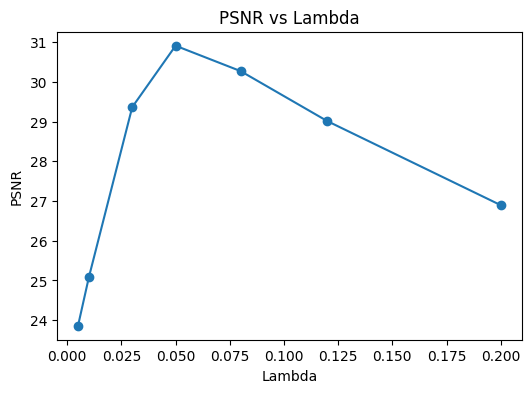

In [ ]:
# create graph from values found in above panel
plt.figure(figsize=(6,4))
plt.title('PSNR vs Lambda')
plt.xlabel('Lambda')
plt.ylabel('PSNR')
plt.plot(lambda_values, psnr_values, marker='o', linestyle='-')
plt.show()

In [ ]:
# compare pnsr at different rho values:
rho_values = [0.1, 0.3, 0.5, 1.0, 2.0, 5.0, 10.0]
rho_psnr_values = []
for rho in rho_values:
    denoised_img, objective_val, primal_val, dual_val = anisotropic_tv_admm(noisy_img1, lam=0.05, rho=rho, max_iter=200)
    psnr = peak_signal_noise_ratio(norm_img1, denoised_img, data_range=1)
    rho_psnr_values.append(psnr)

k: 0 | obj: 1.3168e+03 | primal_res: 6.3333e+01 | dual_res: 1.3318e+01
k: 40 | obj: 5.3500e+02 | primal_res: 1.0367e+00 | dual_res: 1.8062e-02
k: 80 | obj: 5.3013e+02 | primal_res: 4.7081e-01 | dual_res: 5.9829e-03
k: 120 | obj: 5.2849e+02 | primal_res: 2.8840e-01 | dual_res: 3.1267e-03
k: 160 | obj: 5.2769e+02 | primal_res: 2.0163e-01 | dual_res: 1.8093e-03
k: 199 | obj: 5.2724e+02 | primal_res: 1.5299e-01 | dual_res: 1.2357e-03
k: 0 | obj: 1.3168e+03 | primal_res: 5.2486e+01 | dual_res: 3.3757e+01
k: 40 | obj: 5.2848e+02 | primal_res: 2.8655e-01 | dual_res: 2.2186e-02
k: 80 | obj: 5.2693e+02 | primal_res: 1.2003e-01 | dual_res: 6.7249e-03
k: 120 | obj: 5.2646e+02 | primal_res: 6.9775e-02 | dual_res: 3.1524e-03
k: 160 | obj: 5.2625e+02 | primal_res: 4.7543e-02 | dual_res: 1.8597e-03
k: 199 | obj: 5.2614e+02 | primal_res: 3.4955e-02 | dual_res: 1.1305e-03
k: 0 | obj: 1.3168e+03 | primal_res: 3.9872e+01 | dual_res: 4.2311e+01
k: 40 | obj: 5.2727e+02 | primal_res: 1.5430e-01 | dual_res: 

In [ ]:
# compare pnsr at different rho values:
rho_values = [0.1, 0.3, 0.5, 1.0, 2.0, 5.0, 10.0]
rho_psnr_values = []
for rho in rho_values:
    denoised_img, objective_val, primal_val, dual_val = anisotropic_tv_admm(noisy_img1, lam=0.05, rho=rho, max_iter=200)
    psnr = peak_signal_noise_ratio(norm_img1, denoised_img, data_range=1)
    rho_psnr_values.append(psnr)

k: 0 | obj: 1.3168e+03 | primal_res: 6.3333e+01 | dual_res: 1.3318e+01
k: 40 | obj: 5.3500e+02 | primal_res: 1.0367e+00 | dual_res: 1.8062e-02
k: 80 | obj: 5.3013e+02 | primal_res: 4.7081e-01 | dual_res: 5.9829e-03
k: 120 | obj: 5.2849e+02 | primal_res: 2.8840e-01 | dual_res: 3.1267e-03
k: 160 | obj: 5.2769e+02 | primal_res: 2.0163e-01 | dual_res: 1.8093e-03
k: 199 | obj: 5.2724e+02 | primal_res: 1.5299e-01 | dual_res: 1.2357e-03
k: 0 | obj: 1.3168e+03 | primal_res: 5.2486e+01 | dual_res: 3.3757e+01
k: 40 | obj: 5.2848e+02 | primal_res: 2.8655e-01 | dual_res: 2.2186e-02
k: 80 | obj: 5.2693e+02 | primal_res: 1.2003e-01 | dual_res: 6.7249e-03
k: 120 | obj: 5.2646e+02 | primal_res: 6.9775e-02 | dual_res: 3.1524e-03
k: 160 | obj: 5.2625e+02 | primal_res: 4.7543e-02 | dual_res: 1.8597e-03
k: 199 | obj: 5.2614e+02 | primal_res: 3.4955e-02 | dual_res: 1.1305e-03
k: 0 | obj: 1.3168e+03 | primal_res: 3.9872e+01 | dual_res: 4.2311e+01
k: 40 | obj: 5.2727e+02 | primal_res: 1.5430e-01 | dual_res: 

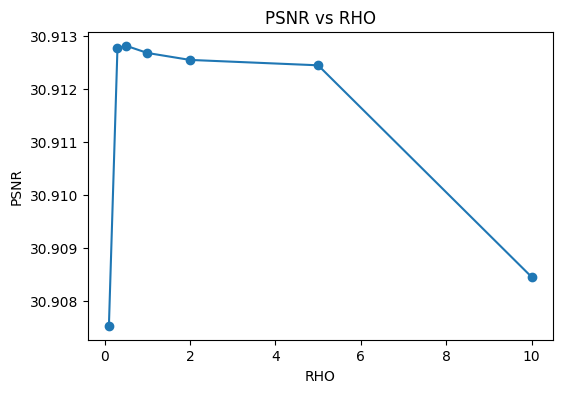

In [ ]:
# create graph from values found in above panel
plt.figure(figsize=(6,4))
plt.title('PSNR vs RHO')
plt.xlabel('RHO')
plt.ylabel('PSNR')
plt.plot(rho_values, rho_psnr_values, marker='o', linestyle='-')
plt.show()